In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[
        "Feature1",
        "Feature2",
        "Feature3",
        "Feature4",
        "Feature5",
        "Feature6"
    ]
)

df["Target"] = y

df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Target
0,-1.700306,0.546738,1.697493,1.020916,-3.568689,1.301264,1
1,0.041412,1.157294,0.140774,-3.193412,2.094181,-1.021301,0
2,1.161560,-0.397759,-1.908699,-1.800386,4.323467,-2.244412,1
3,-1.486318,1.104109,-1.306469,-4.843622,3.572225,-2.327224,0
4,1.916012,-1.199254,-2.594574,-0.640792,5.089422,-2.763972,1


In [3]:
df["Target"].value_counts()

Target
0    501
1    499
Name: count, dtype: int64

In [4]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
svm = SVC()

svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [8]:
y_pred = svm.predict(X_test)

In [9]:
accuracy_score(y_test, y_pred)

0.91

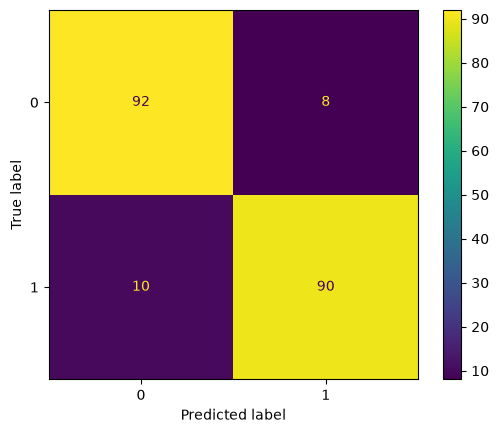

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       100
           1       0.92      0.90      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



In [12]:
linear_model = SVC(kernel="linear")

linear_model.fit(X_train, y_train)

pred = linear_model.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, pred))

Linear Accuracy: 0.715


In [13]:
poly_model = SVC(
    kernel="poly",
    degree=3
)

poly_model.fit(X_train, y_train)

pred = poly_model.predict(X_test)

print("Polynomial Accuracy:", accuracy_score(y_test, pred))

Polynomial Accuracy: 0.735


In [14]:
rbf_model = SVC(
    kernel="rbf"
)

rbf_model.fit(X_train, y_train)

pred = rbf_model.predict(X_test)

print("RBF Accuracy:", accuracy_score(y_test, pred))

RBF Accuracy: 0.91


In [15]:
sigmoid_model = SVC(
    kernel="sigmoid"
)

sigmoid_model.fit(X_train, y_train)

pred = sigmoid_model.predict(X_test)

print("Sigmoid Accuracy:", accuracy_score(y_test, pred))

Sigmoid Accuracy: 0.605


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.1, 1, "scale", "auto"],
    "kernel": ["linear", "rbf", "poly", "sigmoid"]
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best CV score
print("Best CV Accuracy:", grid.best_score_)

# Best model
best_model = grid.best_estimator_
print("Best Model:", best_model)

# Test prediction
pred = best_model.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, pred)
print("Test Accuracy:", test_accuracy)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9324999999999999
Best Model: SVC(C=1)
Test Accuracy: 0.91
